# Trabajo Final procesamiento de lenguaje natural (NLP) <a class="tocSkip">
## Universidad Pontificia Bolivariana <a class="tocSkip">

**Estudiante:** Natalia Arboleda Arboleda

**ID:** 000165655



**Subir Este notebook de Trabajo Final en su repositorio de GitHub. y enviar el link en **Microsoft TEAMS**

Docente: [Jose R. Zapata](https://joserzapata.github.io)
- https://joserzapata.github.io
- https://www.linkedin.com/in/jose-ricardo-zapata-gonzalez/       


## Objetivo del Trabajo
Realizar un proceso de Procesamiento de lenguaje natural (NLP) para dejar los datos preparados para ser usados con algoritmos de Machine Learning para Clasificación como objetivo final del trabajo.

los datos preparados para ser usados con algoritmos de Machine Learning para Regresión o Clasificación como objetivo final del trabajo.

El trabajo se realizara en este jupyter notebook y subirlo a su repositorio de github creado en clase. (**Recuerde poner su nombre e información**)

## Las actividades a realizar
    

1) Limpiar los datos de texto.

   - https://joserzapata.github.io/courses/nlp/procesamiento-basico/

   - https://joserzapata.github.io/courses/nlp/preprocesamiento-texto/

2) Realizar la representación de texto:

   - https://joserzapata.github.io/courses/nlp/representaciones/

   - Tokenización
   - Lematización o stemming
   - Representación de los datos de texto (Bag of Words o TF-IDF)

3) Utilice un modelo de Machine Learning para clasificación para entrenar y evaluar el modelo.
        
    - Calcule estas las métricas de evaluación (accuracy, precision, recall, f1-score) - https://joserzapata.github.io/courses/python-ciencia-datos/clasificacion/#evaluacion-modelo-simple


    
   
    
*NOTA: No dude en contactarme para cualquier pregunta o inquietud :) por el chat de Teams o al correo
joser.zapata@upb.edu.co*

## EVALUACIÓN


|Porcentaje en la evaluación | Descripción| Nada | Incompleto | Completo 
| :---: |:---: |:---: |:---: |:---: 
| 5 % |**limpieza de los datos** |
| 5 % | **Representacion de los datos** |
| 5 % | **Machine Learning** <br> Entrenar y evaluar el modelo propuesto |


In [2]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)
from sklearn.model_selection import train_test_split
import numpy as np

Carga del dataset

El archivo  se carga en aproximadamente 10 segundos

In [ ]:
# Usar su ID UPB Ejemplo: "0028984798"
id_upb = "000165655"

data_reviews = pd.read_parquet(
    "https://www.dropbox.com/scl/fi/gvk9yj8cn96oocr9z058x/filmaffinity_reviews_dataset.parquet?rlkey=xgvr00zvkxbkwqqavqutpsshg&st=xjb7xze9&dl=1",
    engine="fastparquet",
)
data_reviews = data_reviews.sample(n=50_000, random_state=int(id_upb))
data_reviews.info()

Ejemplo de algunas filas del dataset

In [ ]:
data_reviews.sample(5)

,author_review_desc,author_rating
44281,"\nMagnifica. He estado leyendo las criticas, p...",9
38736,"\nJuliette Binoche maneja y habla en inglés, l...",6
58168,\nEl inicio de la película resulta muy interes...,2
130400,\nUna ambiciosa y conmovedora exploración de l...,9
32958,\n...Sumamente instructiva. Así como sintética...,10


Evaluar los valores nulos

In [ ]:
data_reviews.isnull().sum()

author_review_desc    0
author_rating         0
dtype: int64

En este caso no hay nulos.

Revisar si hay valores duplicados:

In [ ]:
data_reviews.duplicated().sum()

np.int64(0)

No hay  valores duplicados.

## Clasificación Tradicional para Análisis de Sentimientos y Categorías 👍 👎



Definición: Se considera reseña positiva cuando la puntuación ("author_rating") es mayor que 6; negativa en caso contrario.

Crear la variable binaria de sentimiento: 1 (positivo) si author_rating > 6, 0 (negativo) de lo contrario

In [ ]:
UMBRAL = 6
data_reviews["sentiment_bin"] = (data_reviews["author_rating"] > UMBRAL).astype(int)

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba

X_data = data_reviews["author_review_desc"]
y_data = data_reviews["sentiment_bin"]


Dividir el dataset en entrenamiento y prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_data,
    test_size=0.2,
    stratify=y_data,  # Mantener la proporción de clases en ambos conjuntos
    random_state=42,
)

## Análisis exploratorio de los datos

para determinar que tipo de limpieza se debe realizar a los datos de texto de `X_train`

In [ ]:
X_train.info()

<class 'pandas.core.series.Series'>
Index: 40000 entries, 46056 to 75983
Series name: author_review_desc
Non-Null Count  Dtype 
--------------  ----- 
40000 non-null  object
dtypes: object(1)
memory usage: 625.0+ KB


In [ ]:
X_train.head()

46056     \nCon las tres entregas de Bourne con el actor...
78060     \nEn el año 2006 vi el trailer de una película...
143363    \nPosiblemente una de las mejores series españ...
110486    \nEl principal problema de esta película, desd...
98822     \nEs decir, la que ve esta película y piensa q...
Name: author_review_desc, dtype: object

In [ ]:
X_train.tail()

90148     \nMichel Franco va al grano, no se anda con su...
144613    \nDamas y caballeros, si esto es un peliculón....
116092    \nQue pasa cuando un Hito del terror, es tan s...
61423     \nSiempre se dice que David W. Griffith y Orso...
75983     \nSerá porque yo ya tengo unos añitos, y se me...
Name: author_review_desc, dtype: object

## 1) Limpieza de los datos de texto

Tomar los datos de `X_train` y aplicar las funciones de limpieza que considere necesarias

Ayudas:

- Convertir a minúsculas
- Eliminar caracteres especiales y números
- Corregir palabras mal escritas
- etc


In [ ]:
import re
import string


def limpiar_texto(text: str) -> str:
    """Preprocesa el texto realizando los siguientes pasos:
    1. Convertir a minúsculas.
    2. Eliminar acentos de vocales.
    3. Eliminar textos entre corchetes (ej.: etiquetas).
    4. Eliminar URLs.
    5. Eliminar etiquetas HTML.
    6. Eliminar signos de puntuación.
    7. Eliminar saltos de línea.
    8. Eliminar palabras que contienen números.
    9. Eliminar emojis y caracteres especiales (no ASCII), excepto la ñ.
    10. Eliminar espacios extras entre palabras.
    11. Eliminar espacios extras al inicio y final.

    Args:
        text (str): El texto a procesar.
    Returns:
        str: El texto preprocesado.

    Example:
        >>> text_preprocess("¡Hola! Visita https://example.com para más info.")
        'hola visita para mas info'


    """
    # Convertir a minúsculas
    text = str(text).lower()

    # Eliminar acentos de vocales
    MAP_VOCALES = {
        "á": "a",
        "é": "e",
        "í": "i",
        "ó": "o",
        "ú": "u",
        "ü": "u",
    }
    translate = str.maketrans(MAP_VOCALES)
    text = text.translate(translate)

    # Eliminar textos entre corchetes (ej.: etiquetas)
    text = re.sub(r"\[.*?\]", "", text)

    # Eliminar URLs
    text = re.sub(r"https?://\S+|www\.\S+", "", text)

    # Eliminar etiquetas HTML
    text = re.sub(r"<.*?>+", "", text)

    # Eliminar signos de puntuación
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)

    # Eliminar saltos de línea
    text = re.sub(r"\n", " ", text)

    # Eliminar palabras que contienen números
    text = re.sub(r"\w*\d\w*", "", text)

    # Eliminar emojis y caracteres especiales (no ASCII), excepto la ñ
    text = re.sub(r"[^\x00-\x7Fñ]+", "", text)

    # Eliminar espacios extras entre palabras
    text = re.sub(r"\s+", " ", text)

    # Eliminar espacios extras al inicio y final
    text = text.strip()

    return text

In [ ]:
X_train = X_train.apply(limpiar_texto)
X_train.head()

46056     con las tres entregas de bourne con el actor m...
78060     en el año vi el trailer de una pelicula llamad...
143363    posiblemente una de las mejores series español...
110486    el principal problema de esta pelicula desde m...
98822     es decir la que ve esta pelicula y piensa que ...
Name: author_review_desc, dtype: object

Tokenización y Segmentación de Reseñas 

Con NLTK

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

# Descargar recursos de tokenización para español

nltk.download("punkt_tab")
sample_text = X_train.iloc[0]
print("Texto de ejemplo:", sample_text)


Texto de ejemplo: con las tres entregas de bourne con el actor matt damon se cierra una trilogia de oro en el genero de espias tres estupendas peliculas que pese a todo en su tercera el ultimatum encontre un poco de fatiga en la serie con unas escenas que se hacian algo repetitivas a pesar de esto muchas sagas querrian tener una trilogia tan completa como esta he estado observando muchas criticas a esta nueva entrega parece ser que muchas de ellas consisten en la sustitucion de matt damon mas alla de valorar la participacion de damon o no hay que destacar la actuacion de jeremy renner que ha sido soberbia cierto es que se echa en falta un guion mas solido o trabajado pero no nos equivoquemos han querido darle un giro nuevo a la saga y han apostado por la accion mas que por el guion y en este aspecto lo han conseguido si las anteriores han destacado por sus grandes dosis de accion esta no se ha quedado manca sino ahi queda la persecucion final por las calles y tejados de manilatodo un l

[nltk_data] Downloading package punkt_tab to /home/vscode/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
tokens_nltk = word_tokenize(sample_text, language="spanish")
sentences_nltk = sent_tokenize(sample_text, language="spanish")

In [ ]:
print("Tokens con nltk:", tokens_nltk)
print("Oraciones con nltk:", sentences_nltk)

Tokens con nltk: ['con', 'las', 'tres', 'entregas', 'de', 'bourne', 'con', 'el', 'actor', 'matt', 'damon', 'se', 'cierra', 'una', 'trilogia', 'de', 'oro', 'en', 'el', 'genero', 'de', 'espias', 'tres', 'estupendas', 'peliculas', 'que', 'pese', 'a', 'todo', 'en', 'su', 'tercera', 'el', 'ultimatum', 'encontre', 'un', 'poco', 'de', 'fatiga', 'en', 'la', 'serie', 'con', 'unas', 'escenas', 'que', 'se', 'hacian', 'algo', 'repetitivas', 'a', 'pesar', 'de', 'esto', 'muchas', 'sagas', 'querrian', 'tener', 'una', 'trilogia', 'tan', 'completa', 'como', 'esta', 'he', 'estado', 'observando', 'muchas', 'criticas', 'a', 'esta', 'nueva', 'entrega', 'parece', 'ser', 'que', 'muchas', 'de', 'ellas', 'consisten', 'en', 'la', 'sustitucion', 'de', 'matt', 'damon', 'mas', 'alla', 'de', 'valorar', 'la', 'participacion', 'de', 'damon', 'o', 'no', 'hay', 'que', 'destacar', 'la', 'actuacion', 'de', 'jeremy', 'renner', 'que', 'ha', 'sido', 'soberbia', 'cierto', 'es', 'que', 'se', 'echa', 'en', 'falta', 'un', 'guio

Con spaCy

In [ ]:
import spacy

nlp_es = spacy.load("es_core_news_sm")
doc_es = nlp_es(sample_text)

tokens_spacy = [token.text for token in doc_es]
sentences_spacy = [sent.text for sent in doc_es.sents]

print("Tokens con spaCy:", tokens_spacy)
print("Oraciones con spaCy:", sentences_spacy)

Tokens con spaCy: ['con', 'las', 'tres', 'entregas', 'de', 'bourne', 'con', 'el', 'actor', 'matt', 'damon', 'se', 'cierra', 'una', 'trilogia', 'de', 'oro', 'en', 'el', 'genero', 'de', 'espias', 'tres', 'estupendas', 'peliculas', 'que', 'pese', 'a', 'todo', 'en', 'su', 'tercera', 'el', 'ultimatum', 'encontre', 'un', 'poco', 'de', 'fatiga', 'en', 'la', 'serie', 'con', 'unas', 'escenas', 'que', 'se', 'hacian', 'algo', 'repetitivas', 'a', 'pesar', 'de', 'esto', 'muchas', 'sagas', 'querrian', 'tener', 'una', 'trilogia', 'tan', 'completa', 'como', 'esta', 'he', 'estado', 'observando', 'muchas', 'criticas', 'a', 'esta', 'nueva', 'entrega', 'parece', 'ser', 'que', 'muchas', 'de', 'ellas', 'consisten', 'en', 'la', 'sustitucion', 'de', 'matt', 'damon', 'mas', 'alla', 'de', 'valorar', 'la', 'participacion', 'de', 'damon', 'o', 'no', 'hay', 'que', 'destacar', 'la', 'actuacion', 'de', 'jeremy', 'renner', 'que', 'ha', 'sido', 'soberbia', 'cierto', 'es', 'que', 'se', 'echa', 'en', 'falta', 'un', 'gui

Eliminación de Stopwords

In [ ]:
from nltk.corpus import stopwords

#Descargar recursos de stopwords en español
nltk.download("stopwords")
stopword_es = set(stopwords.words("spanish"))

# Eliminar stopwords
tokens_no_stop = [word for word in tokens_nltk if word not in stopword_es]
print("Tokens originales:", tokens_nltk)
print("Tokens sin stopwords:", tokens_no_stop)

Tokens originales: ['con', 'las', 'tres', 'entregas', 'de', 'bourne', 'con', 'el', 'actor', 'matt', 'damon', 'se', 'cierra', 'una', 'trilogia', 'de', 'oro', 'en', 'el', 'genero', 'de', 'espias', 'tres', 'estupendas', 'peliculas', 'que', 'pese', 'a', 'todo', 'en', 'su', 'tercera', 'el', 'ultimatum', 'encontre', 'un', 'poco', 'de', 'fatiga', 'en', 'la', 'serie', 'con', 'unas', 'escenas', 'que', 'se', 'hacian', 'algo', 'repetitivas', 'a', 'pesar', 'de', 'esto', 'muchas', 'sagas', 'querrian', 'tener', 'una', 'trilogia', 'tan', 'completa', 'como', 'esta', 'he', 'estado', 'observando', 'muchas', 'criticas', 'a', 'esta', 'nueva', 'entrega', 'parece', 'ser', 'que', 'muchas', 'de', 'ellas', 'consisten', 'en', 'la', 'sustitucion', 'de', 'matt', 'damon', 'mas', 'alla', 'de', 'valorar', 'la', 'participacion', 'de', 'damon', 'o', 'no', 'hay', 'que', 'destacar', 'la', 'actuacion', 'de', 'jeremy', 'renner', 'que', 'ha', 'sido', 'soberbia', 'cierto', 'es', 'que', 'se', 'echa', 'en', 'falta', 'un', 'gu

[nltk_data] Downloading package stopwords to /home/vscode/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Stemming y Lematización

In [ ]:
from nltk.stem import SnowballStemmer
# Seleccionar un ejemplo de reseña limpia
sample_text = X_train.iloc[0]
print("Texto de ejemplo:", sample_text)

# Tokenización con nltk
tokens = word_tokenize(sample_text, language="spanish")

print("Tokens:", tokens)


Texto de ejemplo: con las tres entregas de bourne con el actor matt damon se cierra una trilogia de oro en el genero de espias tres estupendas peliculas que pese a todo en su tercera el ultimatum encontre un poco de fatiga en la serie con unas escenas que se hacian algo repetitivas a pesar de esto muchas sagas querrian tener una trilogia tan completa como esta he estado observando muchas criticas a esta nueva entrega parece ser que muchas de ellas consisten en la sustitucion de matt damon mas alla de valorar la participacion de damon o no hay que destacar la actuacion de jeremy renner que ha sido soberbia cierto es que se echa en falta un guion mas solido o trabajado pero no nos equivoquemos han querido darle un giro nuevo a la saga y han apostado por la accion mas que por el guion y en este aspecto lo han conseguido si las anteriores han destacado por sus grandes dosis de accion esta no se ha quedado manca sino ahi queda la persecucion final por las calles y tejados de manilatodo un l

In [ ]:
# Definir el stemmer para español
stemmer_es = SnowballStemmer("spanish")

# Aplicar stemming
stemmed_tokens = [stemmer_es.stem(token) for token in tokens_no_stop]
print("Tokens después de stemming:", stemmed_tokens)

# Aplicar lematización usando spaCy
doc_es = nlp_es(sample_text)
lemmatized_tokens = [
    token.lemma_ for token in doc_es if token.text.lower() not in stopword_es
]
print("Tokens después de lematización (sin stopwords):", lemmatized_tokens)


Tokens después de stemming: ['tres', 'entreg', 'bourn', 'actor', 'matt', 'damon', 'cierr', 'trilogi', 'oro', 'gener', 'espi', 'tres', 'estupend', 'pelicul', 'pes', 'tercer', 'ultimatum', 'encontr', 'fatig', 'seri', 'unas', 'escen', 'haci', 'repetit', 'pes', 'much', 'sag', 'querri', 'ten', 'trilogi', 'tan', 'complet', 'observ', 'much', 'critic', 'nuev', 'entreg', 'parec', 'ser', 'much', 'consist', 'sustitucion', 'matt', 'damon', 'mas', 'alla', 'valor', 'particip', 'damon', 'destac', 'actuacion', 'jeremy', 'renn', 'sid', 'soberbi', 'ciert', 'echa', 'falt', 'guion', 'mas', 'sol', 'trabaj', 'equivoqu', 'quer', 'darl', 'gir', 'nuev', 'sag', 'apost', 'accion', 'mas', 'guion', 'aspect', 'consegu', 'si', 'anterior', 'destac', 'grand', 'dosis', 'accion', 'qued', 'manc', 'sin', 'ahi', 'qued', 'persecucion', 'final', 'call', 'tej', 'manilatod', 'luj', 'apart', 'persecu', 'modal', 'pie', 'coch', 'mot', 'tras', 'fug', 'inform', 'treadston', 'accion', 'comet', 'bourn', 'ultimatum', 'program', 'conoc

## 2) Representacion del texto

Luego de tener los datos limpios, realizar la representación de los datos de texto para poder usarse en modelos de machine learning.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
corpus = X_train.tolist()

Representación Bag-of-Words con CountVectorizer

In [ ]:
cv = CountVectorizer()
bow_matrix = cv.fit_transform(corpus)
print("Dimensiones de la matriz Bag-of-Words:", bow_matrix.shape)
print(
    "Ejemplo de términos (BoW):",
    np.random.choice(cv.get_feature_names_out(), size=10, replace=False),
)


Dimensiones de la matriz Bag-of-Words: (40000, 144594)
Ejemplo de términos (BoW): ['decora' 'blandir' 'patologo' 'evadidos' 'tiber' 'pestañear' 'tachandose'
 'wolowitz' 'teutonicos' 'dulzura']


Representación TF-IDF con TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(corpus)
print("Dimensiones de la matriz TF-IDF:", tfidf_matrix.shape)
print(
    "Ejemplo de términos (TF-IDF):",
    np.random.choice(tfidf.get_feature_names_out(), size=10, replace=False),
)


Dimensiones de la matriz TF-IDF: (40000, 144594)
Ejemplo de términos (TF-IDF): ['echandoles' 'muñequita' 'gourmesserie' 'shtisel' 'pasandome' 'arenoso'
 'interconectando' 'situen' 'cabezas' 'conversiones']


In [ ]:
# Obtener nombres de términos y TF-IDF promedio por término en todo el corpus
feature_names = tfidf.get_feature_names_out()
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

# Normalizar para interpretar como "probabilidades" (suma 1)
total = mean_tfidf.sum()
probs = mean_tfidf / total if total > 0 else np.zeros_like(mean_tfidf)

# DataFrame con término, tfidf medio y probabilidad normalizada
df_terms = pd.DataFrame(
    {
        "term": feature_names,
        "mean_tfidf": mean_tfidf,
        "probability": probs,
    }
)

print(
    "\nEjemplo aleatorio de 10 términos con su probabilidad (TF-IDF medio normalizado):"
)
print(
    df_terms.sample(10, random_state=2025)
    .sort_values("probability", ascending=False)
    .reset_index(drop=True)
)



Ejemplo aleatorio de 10 términos con su probabilidad (TF-IDF medio normalizado):
         term  mean_tfidf   probability
0     validas    0.000046  4.704229e-06
1    ministra    0.000023  2.420094e-06
2     fluidas    0.000018  1.904252e-06
3     nocilla    0.000017  1.708981e-06
4      xtremo    0.000005  5.502999e-07
5  infestados    0.000003  3.381337e-07
6   gastarles    0.000003  3.192587e-07
7  islamizado    0.000002  2.475492e-07
8  acometeria    0.000002  2.309944e-07
9  otrosojero    0.000002  1.866123e-07


Visualización y Análisis Exploratorio del Texto

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

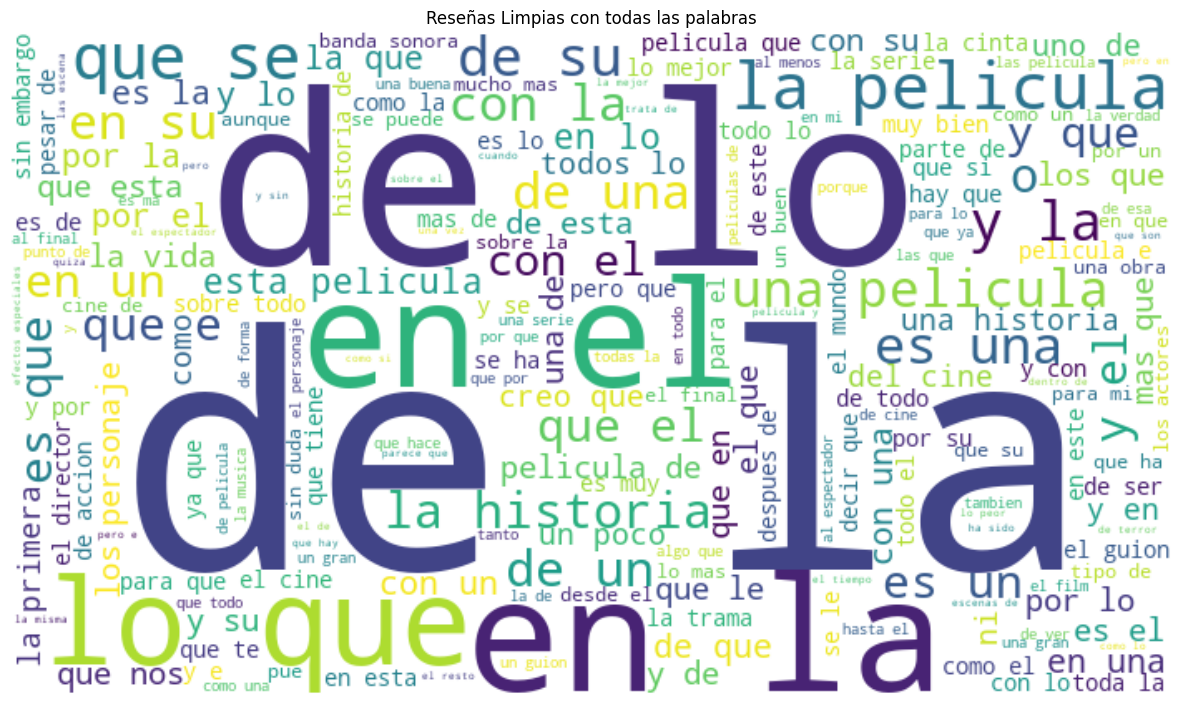

In [ ]:
# Generar nube de palabras con las reseñas limpias
text = " ".join(review for review in X_train)
wordcloud = WordCloud(background_color="white", width=700, height=400).generate(text)

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Reseñas Limpias con todas las palabras")
plt.show()

Reseñas limpias sin stopwords

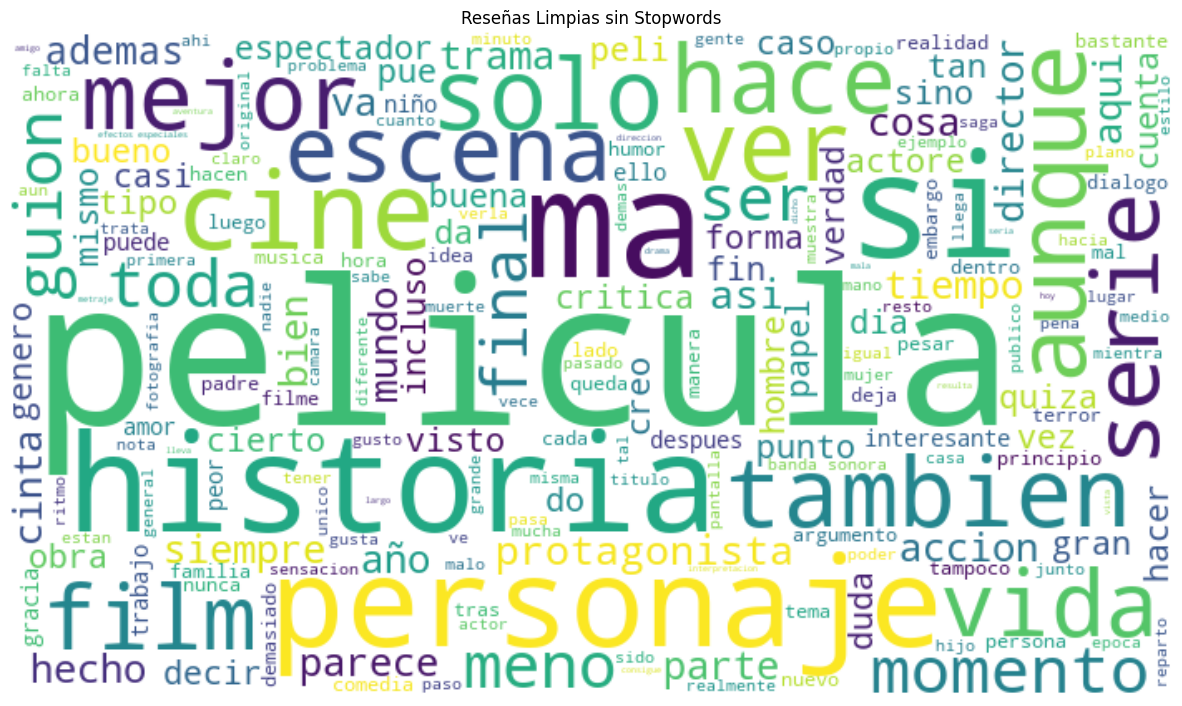

In [ ]:
# Generar nube de palabras con las reseñas limpias sin stopwords
text = " ".join(review for review in X_train)
wordcloud = WordCloud(
    stopwords=stopword_es, background_color="white", width=700, height=400
).generate(text)

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Reseñas Limpias sin Stopwords")
plt.show()


Reseñas Limpias sin Stopwords + Stemming

In [ ]:
def clean_stopwords_and_stemming(text: str) -> str:
    """Elimina stopwords y aplica stemming al texto dado.
    Args:
        text (str): El texto a procesar.
    Returns:
        str: El texto procesado sin stopwords y con stemming aplicado.
    Example:
        >>> clean_stopwords_and_stemming("Este es un ejemplo de texto para procesar.")
        'este ejempl text proces'
    """
    # Eliminar stopwords
    text = " ".join([word for word in text.split() if word not in stopword_es])
    # Aplicar stemming
    text = " ".join([stemmer_es.stem(word) for word in text.split()])
    # Eliminar espacios extras al inicio y final
    return text.strip()

In [ ]:
clean_stopwords_and_stemming("Este es un ejemplo de texto para procesar.")

'este ejempl text procesar.'

In [ ]:
X_train = X_train.apply(
    clean_stopwords_and_stemming
)

# texto limpio avanzado
X_train.head(3)

46056     tres entreg bourn actor matt damon cierr trilo...
78060     año vi trail pelicul llam niñer magic pareci s...
143363    posibl mejor seri español tiemp siempr seri or...
Name: author_review_desc, dtype: object

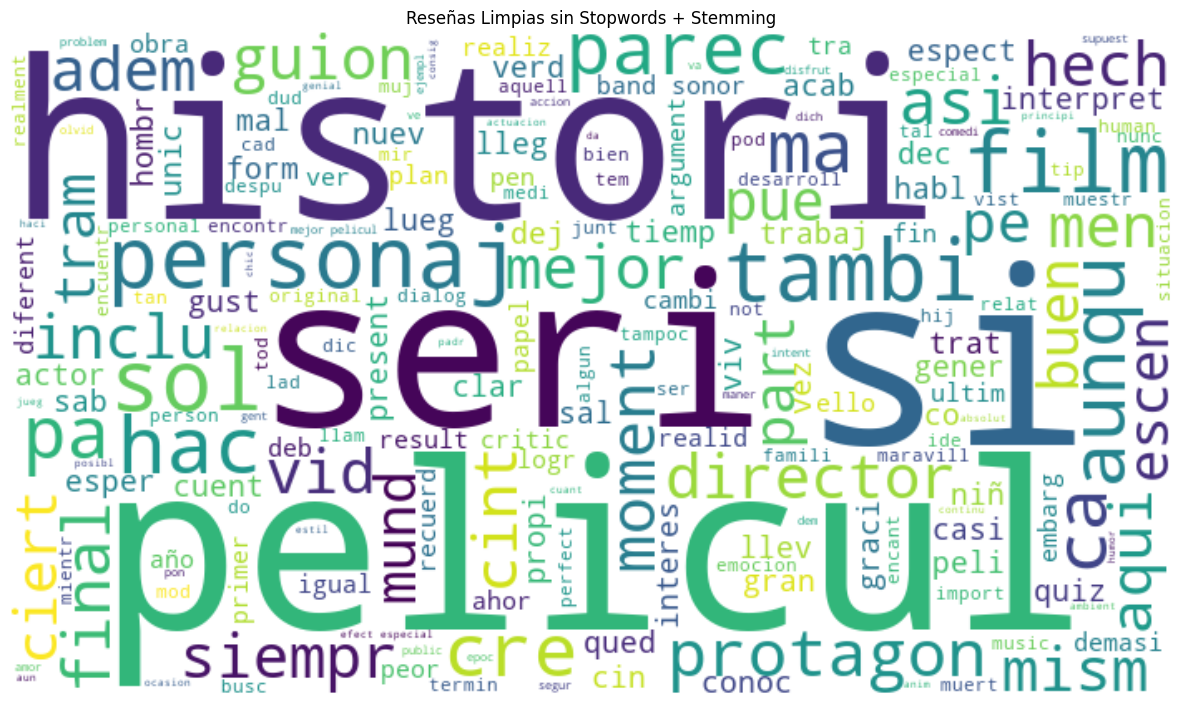

In [ ]:
# Generar nube de palabras con las Reseñas Limpias sin Stopwords + Stemming
text = " ".join(review for review in X_train)
wordcloud = WordCloud(
    stopwords=stopword_es, background_color="white", width=700, height=400
).generate(text)

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Reseñas Limpias sin Stopwords + Stemming")
plt.show()


Reseñas Limpias sin Stopwords + Lemmatization

In [ ]:
def clean_stopwords_and_lemmatization(series: pd.Series) -> pd.Series:
    """
    Elimina stopwords y aplica lematización a una serie de pandas.

    Args:
        series (pd.Series): Serie de pandas con textos a procesar.
    Returns:
        pd.Series: Serie de pandas con textos procesados.
    Example:
        >>> import pandas as pd
        >>> sample_series = pd.Series(["Este es un ejemplo de texto para procesar."])
        >>> clean_stopwords_and_lemmatization(sample_series)
        0    ejemplo texto procesar
        dtype: object
    """

    docs = nlp_es.pipe(
        series.astype(str),
        disable=["parser", "ner"],
        batch_size=256,
        n_process=4,
    )
    cleaned = []
    for doc in docs:
        cleaned.append(
            " ".join(
                token.lemma_ for token in doc if token.text.lower() not in stopword_es
            ).strip()
        )
    return pd.Series(cleaned, index=series.index)


X_train = clean_stopwords_and_lemmatization(
    X_train
)

NameError: name 'pd' is not defined

## 3) Entrenar un modelo de machine learning de clasificación

Utilizar un modelo de clasificación para entrenar y evaluar el modelo con los datos preparados.


### Evaluar el modelo con los datos de prueba

Usar el modelo para predecir en `X_test` y evaluar con `y_test`

**Nota:** Recuerde que `X_test` debe pasar por los mismos procesos de limpieza y representación que `X_train`

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred))
print("Reporte de clasificación:\n", classification_report(y_test, y_pred))

**Guardar el modelo**

In [ ]:
import joblib

## Librerías Usadas

In [ ]:
from watermark import watermark

print(watermark(python=True, iversions=True, globals_=globals()))

---

## Referencias
- [CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)
- [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)
- [Classification of text documents using sparse features](https://scikit-learn.org/stable/auto_examples/text/plot_document_classification_20newsgroups.html)
- Ejemplo de Entrenamiento y selección de Modelo de machine learning entre varios modelos <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/6-model_selection/>
- https://joserzapata.github.io/courses/python-ciencia-datos/python/
- https://joserzapata.github.io/courses/python-ciencia-datos/pandas/
- https://joserzapata.github.io/courses/python-ciencia-datos/machine-learning/

Docente: [Jose R. Zapata](https://joserzapata.github.io)

- [https://joserzapata.github.io/](https://joserzapata.github.io/)
- [https://www.linkedin.com/in/jose-ricardo-zapata-gonzalez/](https://www.linkedin.com/in/jose-ricardo-zapata-gonzalez/)